# 01. Análisis Exploratorio de Datos (EDA) y Limpieza
### Detección Temprana de Abandono de Clientes (*Customer Churn*)

En este notebook ejecutamos el diagnóstico de calidad de datos, tratamiento de valores nulos/inconsistencias y el análisis exploratorio bivariado para entender qué factores impulsan la deserción de clientes en la plataforma de e-commerce.

---
### Contenido:
1. **Configuración y Carga de Datos**
2. **Diagnóstico de Calidad (Nulos, Tipos y Duplicados)**
3. **Estandarización y Tratamiento de Nulos**
4. **Análisis Univariado de la Variable Objetivo (`Churn`)**
5. **Análisis Bivariado (Drivers de Abandono: Quejas, Antigüedad, Satisfacción)**
6. **Matriz de Correlación**
7. **Exportación del Dataset Limpio**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Entorno y librerías cargadas exitosamente.")


Entorno y librerías cargadas exitosamente.


## 1. Carga de Datos e Inspección Inicial

In [2]:
df_raw = pd.read_csv('../data/raw/ecommerce_data.csv')
df_dict = pd.read_csv('../data/raw/data_dictionary.csv')

print(f"Dimensiones del dataset: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")
df_raw.head()


Dimensiones del dataset: 5630 filas, 20 columnas


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
# Diccionario de variables del dataset
df_dict


,Variable,Description
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


## 2. Diagnóstico de Calidad de Datos

In [4]:
# Verificación de duplicados por CustomerID
duplicados = df_raw.duplicated(subset=['CustomerID']).sum()
print(f"IDs duplicados: {duplicados}")

# Resumen de valores nulos
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw)) * 100
resumen_nulos = pd.DataFrame({'Total Nulos': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)
resumen_nulos


IDs duplicados: 0


,Total Nulos,Porcentaje (%)
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


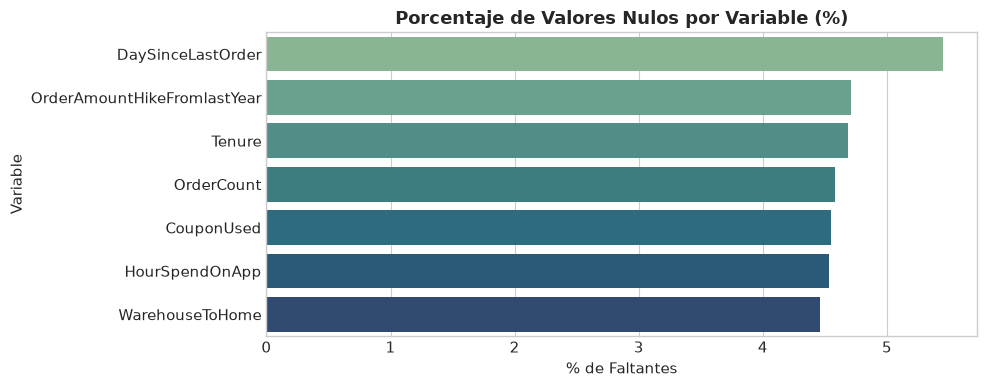

In [5]:
# Visualización gráfica de columnas con datos faltantes
if not resumen_nulos.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=resumen_nulos['Porcentaje (%)'], y=resumen_nulos.index, palette='crest')
    plt.title('Porcentaje de Valores Nulos por Variable (%)', fontsize=13, weight='bold')
    plt.xlabel('% de Faltantes')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()


## 3. Limpieza, Estandarización e Imputación

Revisamos valores categóricos inconsistentes (ej. `Phone` vs `Mobile Phone`, o `COD` vs `Cash on Delivery`) e imputamos los valores nulos numéricos con la mediana para evitar distorsiones por valores atípicos.


In [6]:
df_clean = df_raw.copy()

# 1. PreferredLoginDevice: unificar 'Phone' con 'Mobile Phone'
df_clean['PreferredLoginDevice'] = df_clean['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

# 2. PreferredPaymentMode: unificar 'CC' con 'Credit Card', y 'COD' con 'Cash on Delivery'
df_clean['PreferredPaymentMode'] = df_clean['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})

# 3. PreferedOrderCat: unificar 'Mobile' con 'Mobile Phone'
df_clean['PreferedOrderCat'] = df_clean['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

# Imputación de valores nulos con la mediana para variables numéricas
cols_con_nulos = resumen_nulos.index.tolist()
for col in cols_con_nulos:
    mediana = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana)

print(f"Valores nulos restantes tras la imputación: {df_clean.isnull().sum().sum()}")


Valores nulos restantes tras la imputación: 0


## 4. Distribución de la Variable Objetivo (`Churn`)

Analizamos el grado de balanceo de las clases:
* `0`: Cliente Activo / Retenido
* `1`: Cliente que Desertó (*Churned*)


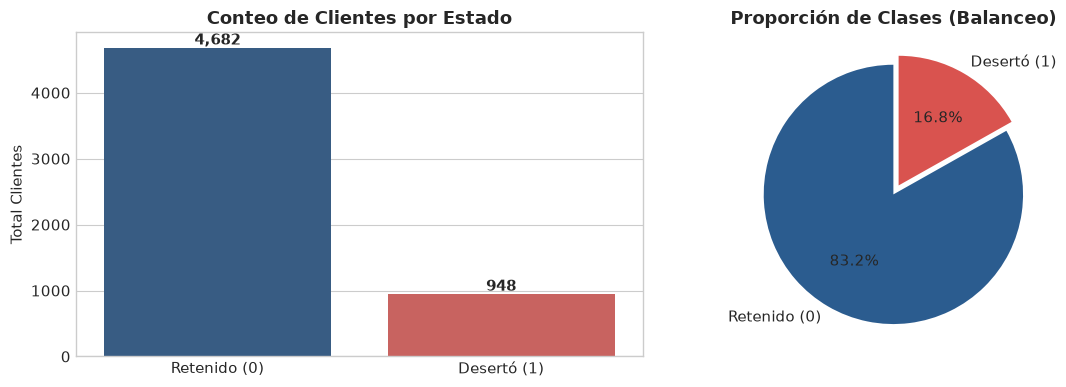

Tasa global de deserción: 16.84%


In [7]:
conteo_churn = df_clean['Churn'].value_counts()
pct_churn = df_clean['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
sns.barplot(x=['Retenido (0)', 'Desertó (1)'], y=conteo_churn.values, ax=ax[0], palette=['#2b5c8f', '#d9534f'])
ax[0].set_title('Conteo de Clientes por Estado', weight='bold')
ax[0].set_ylabel('Total Clientes')
for i, v in enumerate(conteo_churn.values):
    ax[0].text(i, v + 50, f'{v:,}', ha='center', weight='bold')

# Gráfico de dona
ax[1].pie(pct_churn, labels=['Retenido (0)', 'Desertó (1)'], autopct='%.1f%%', colors=['#2b5c8f', '#d9534f'], startangle=90, explode=[0, 0.08])
ax[1].set_title('Proporción de Clases (Balanceo)', weight='bold')

plt.tight_layout()
plt.show()

print(f"Tasa global de deserción: {pct_churn[1]:.2f}%")


## 5. Análisis Bivariado: ¿Qué factores disparan el Churn?

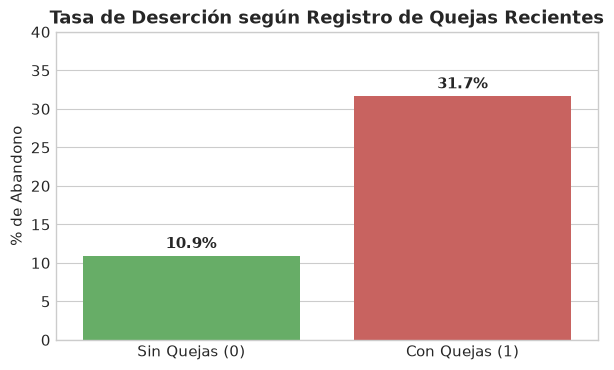

In [8]:
# 5.1 Impacto de las Quejas (Complain) en el Churn
tasa_quejas = df_clean.groupby('Complain')['Churn'].mean() * 100

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=['Sin Quejas (0)', 'Con Quejas (1)'], y=tasa_quejas.values, palette=['#5cb85c', '#d9534f'])
plt.title('Tasa de Deserción según Registro de Quejas Recientes', weight='bold')
plt.ylabel('% de Abandono')
for i, v in enumerate(tasa_quejas.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', weight='bold')
plt.ylim(0, 40)
plt.show()


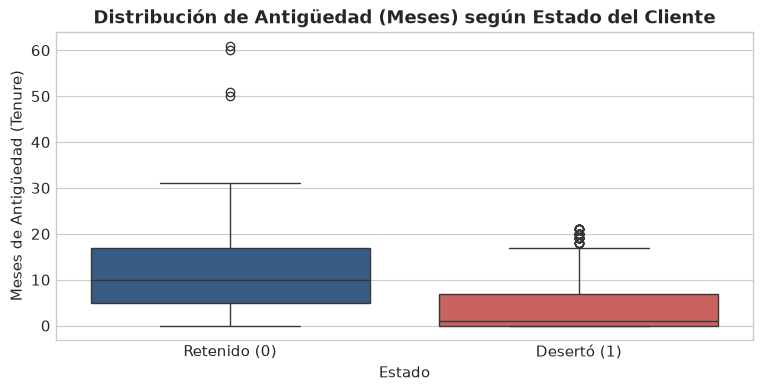

In [9]:
# 5.2 Antigüedad (Tenure) vs Churn
plt.figure(figsize=(9, 4))
sns.boxplot(x='Churn', y='Tenure', data=df_clean, palette=['#2b5c8f', '#d9534f'])
plt.xticks([0, 1], ['Retenido (0)', 'Desertó (1)'])
plt.title('Distribución de Antigüedad (Meses) según Estado del Cliente', weight='bold')
plt.xlabel('Estado')
plt.ylabel('Meses de Antigüedad (Tenure)')
plt.show()


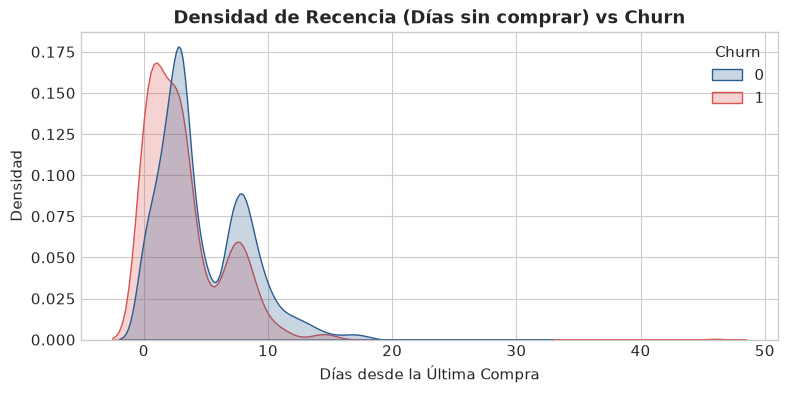

In [10]:
# 5.3 Días desde la última compra (DaySinceLastOrder) vs Churn
plt.figure(figsize=(9, 4))
sns.kdeplot(data=df_clean, x='DaySinceLastOrder', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True)
plt.title('Densidad de Recencia (Días sin comprar) vs Churn', weight='bold')
plt.xlabel('Días desde la Última Compra')
plt.ylabel('Densidad')
plt.show()


## 6. Matriz de Correlación Lineal

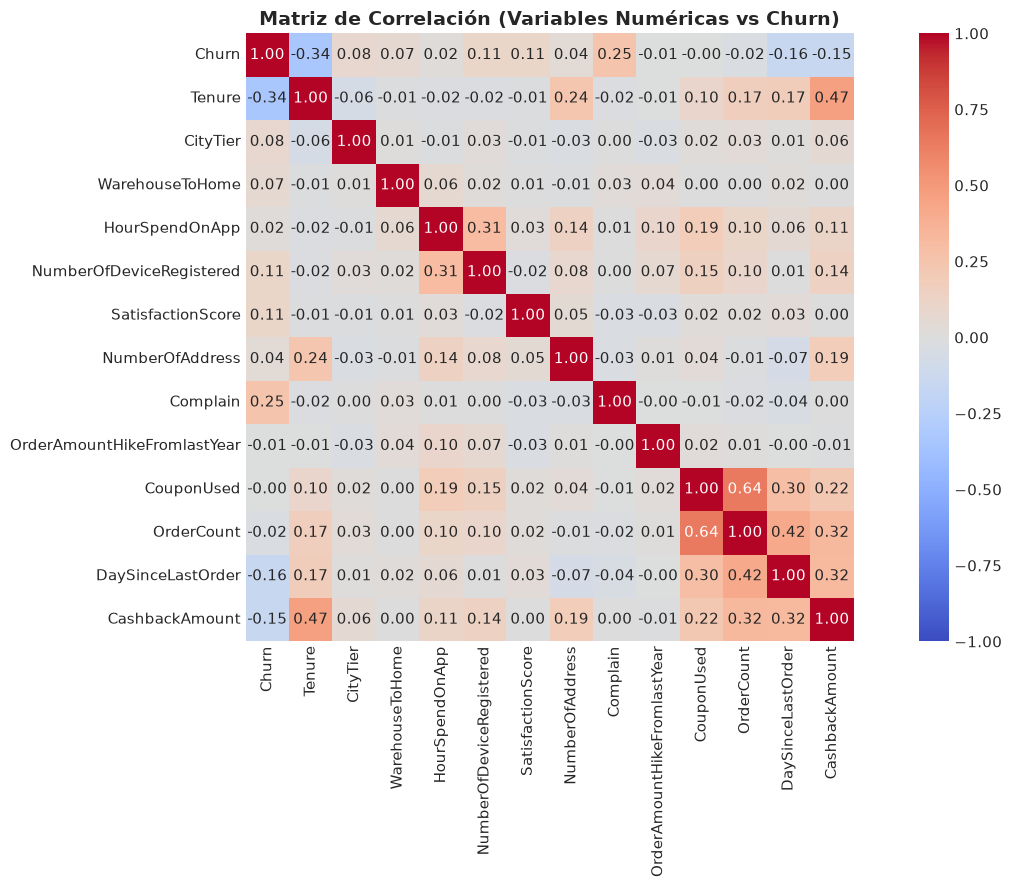

Correlación directa con la variable Churn:
Tenure                        -0.337831
DaySinceLastOrder             -0.155871
CashbackAmount                -0.154118
OrderCount                    -0.024038
OrderAmountHikeFromlastYear   -0.007075
CouponUsed                    -0.001430
HourSpendOnApp                 0.018816
NumberOfAddress                0.043931
WarehouseToHome                0.069544
CityTier                       0.084703
SatisfactionScore              0.105481
NumberOfDeviceRegistered       0.107939
Complain                       0.250188
Name: Churn, dtype: float64


In [11]:
# Seleccionamos variables numéricas para la correlación
cols_num = df_clean.select_dtypes(include=[np.number]).columns.drop('CustomerID')
corr = df_clean[cols_num].corr()

plt.figure(figsize=(14, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True, square=True)
plt.title('Matriz de Correlación (Variables Numéricas vs Churn)', weight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Variables con mayor correlación con Churn
corr_churn = corr['Churn'].drop('Churn').sort_values()
print("Correlación directa con la variable Churn:")
print(corr_churn)


## 7. Exportación del Dataset Procesado

In [12]:
output_path = '../data/processed/ecommerce_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"Dataset limpio guardado exitosamente en: {output_path}")
print(f"Dimensiones finales: {df_clean.shape[0]} filas, {df_clean.shape[1]} columnas")


Dataset limpio guardado exitosamente en: ../data/processed/ecommerce_cleaned.csv
Dimensiones finales: 5630 filas, 20 columnas


## 8. Hallazgos Clave del EDA

1. **Desbalance Moderado:** La tasa global de deserción es de ~16.8%, lo cual es común en e-commerce. En la fase de modelado usaremos `class_weight='balanced'` para que los algoritmos presten suficiente atención a los desertores.
2. **El Factor Crítico de las Quejas (`Complain`):** Los clientes que registraron una queja en el último mes tienen una tasa de fuga cercana al **31.7%**, comparado con solo el **10.8%** de quienes no se quejaron (¡casi 3 veces más riesgo!).
3. **Curva de Riesgo en Nuevos Clientes (`Tenure`):** La gran mayoría de abandonos ocurre en los primeros meses de permanencia (antigüedad baja). Si el cliente supera los primeros 6-12 meses, la fidelización aumenta drásticamente.
4. **Recencia:** Días prolongados sin compra incrementan la propensión al abandono.

---
**Próximo paso:** Pasar a `notebooks/02_modelado_predictivo.ipynb` para dividir train/test, codificar variables y entrenar Regresión Logística vs. XGBoost.
